## Neural Network Architecture Visualization

In [ ]:
!pip install matplotlib tensorflow

Creating the actual Neural Network (Keras)

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Sequential Model
model = models.Sequential(name="Credit_Card_Fraud_Model")
# Input Layer: 6 features [Amount, Time, Category, Age, Balance, TransactionsToday]
model.add(layers.Input(shape=(6,), name='Input_Features'))
# Hidden Layer 1: 8 neurons 
model.add(layers.Dense(8, activation='relu', name='Hidden_1'))
# Hidden Layer 2: 4 neurons (distilling information)
model.add(layers.Dense(4, activation='relu', name='Hidden_2'))
# Output Layer: 1 neuron (Binary Classification)
model.add(layers.Dense(1, activation='sigmoid', name='Output_Layer'))
# Summary
model.summary()

Model: "Credit_Card_Fraud_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_1 (Dense)                │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
import matplotlib.pyplot as plt

def draw_tf_model_with_features(model, feature_names):
    # Layer sizes: input + Dense layers
    layer_sizes = [len(feature_names)] + [layer.units for layer in model.layers]

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.axis('off')

    x_gap = 2.5
    y_gap = 1.2
    max_neurons = max(layer_sizes)

    prev_positions = []

    for layer_idx, neurons in enumerate(layer_sizes):
        x = layer_idx * x_gap
        y_start = (max_neurons - neurons) * y_gap / 2
        current_positions = []

        for neuron_idx in range(neurons):
            y = y_start + neuron_idx * y_gap
            ax.add_patch(plt.Circle((x, y), 0.15, fill=True))
            current_positions.append((x, y))

            # Label input features
            if layer_idx == 0:
                ax.text(
                    x - 0.3, y,
                    feature_names[neuron_idx],
                    ha='right', va='center', fontsize=9
                )

            # Label output
            if layer_idx == len(layer_sizes) - 1:
                ax.text(
                    x + 0.3, y,
                    "Fraud\n(0/1)",
                    ha='left', va='center', fontsize=9
                )

        # Draw connections
        if prev_positions:
            for (x1, y1) in prev_positions:
                for (x2, y2) in current_positions:
                    ax.plot([x1, x2], [y1, y2], linewidth=0.5)

        prev_positions = current_positions

    # Layer titles
    layer_titles = [
        "Input Layer",
        "Hidden Layer 1\n(ReLU)",
        "Hidden Layer 2\n(ReLU)",
        "Output Layer\n(Sigmoid)"
    ]

    for i, title in enumerate(layer_titles):
        ax.text(i * x_gap, max_neurons * y_gap / 1.25 + 0.8,
                title, ha='center', fontsize=10, fontweight='bold')

    plt.title("Neural Network Architecture for Credit Card Fraud Detection", fontsize=12)
    plt.show()


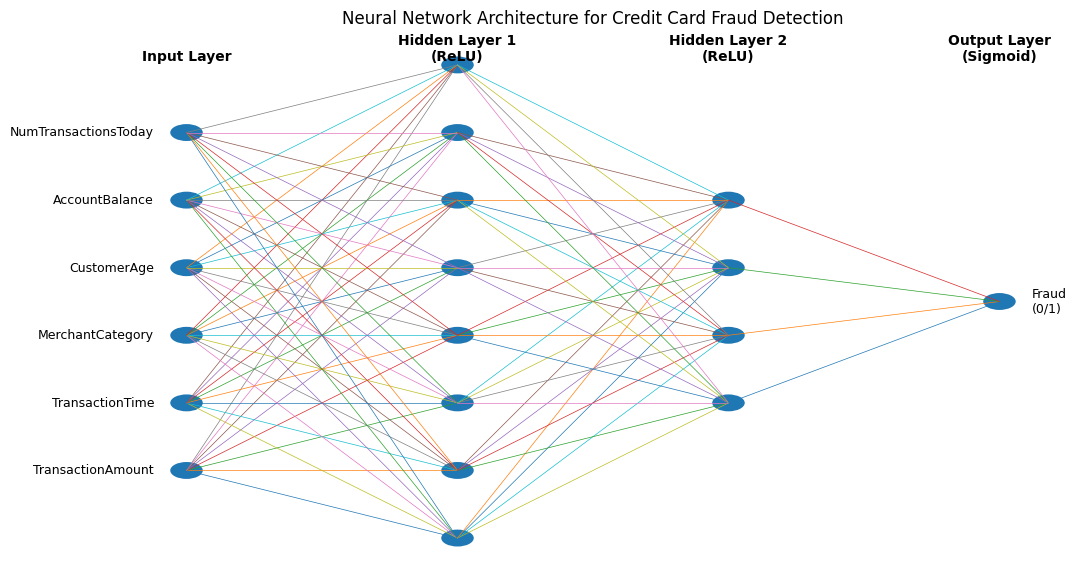

In [23]:
feature_names = [
    "TransactionAmount",
    "TransactionTime",
    "MerchantCategory",
    "CustomerAge",
    "AccountBalance",
    "NumTransactionsToday"
]

draw_tf_model_with_features(model, feature_names)